In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import datetime

In [2]:
systems_cleaned = pd.read_csv('../../data/core/systems_cleaned.csv')

In [3]:
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'num_days_actual_records', 'sample_year'],
      dtype='str')

In [6]:
systems_cleaned[['sample_year']].value_counts()

sample_year
0              1701
2013             52
2012             39
2014             35
2011             10
2015              6
2016              5
1995              2
2010              2
2008              1
2007              1
1999              1
2003              1
2001              1
2017              1
2009              1
Name: count, dtype: int64

In [10]:
systems_cleaned[systems_cleaned['system_id'] == 36]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records
7,36,NREL low-X x-Si -1,"Golden, CO",7,39.704,-105.1773,1794.7,2.21,BSk,12,...,True,True,True,True,True,True,Unknown,unknown,PVDAQ General,2516


In [4]:
all_data_systems = systems_cleaned[
    systems_cleaned['has_current_data']
    & systems_cleaned['has_irradiance_data']
    & systems_cleaned['has_power_data']
    & systems_cleaned['has_temperature_data']
    & systems_cleaned['has_voltage_data']
]
all_data_ids = set(all_data_systems.system_id)

In [5]:
all_parquet_systems = systems_cleaned[
    systems_cleaned['is_lake_csv_data']
]
all_parquet_ids = set(all_parquet_systems.system_id)

In [6]:
rich_parquet_data_ids = all_parquet_ids.intersection(all_data_ids, metrics_id_set)
rich_parquet_systems = systems_cleaned[systems_cleaned['system_id'].isin(rich_parquet_data_ids)]

NameError: name 'metrics_id_set' is not defined

In [18]:
rich_parquet_systems['num_days_actual_records'].describe()

count      40.000000
mean     2672.850000
std      1811.215834
min       404.000000
25%      1325.000000
50%      2342.000000
75%      3415.000000
max      8455.000000
Name: num_days_actual_records, dtype: float64

In [19]:
rich_parquet_systems[rich_parquet_systems['num_days_actual_records'] < 2*365]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records
82,1305,[1305] St. Petersburg Parks CDP - Azalea Park ...,"St Petersburg, FL",America/New_York,27.7863,-82.7379,5.0,NaN,Cfa,45,...,True,True,True,True,True,True,Unknown,unknown,PVDAQ General,703
83,1306,[1306] St. Petersburg Parks CDP - Campbell Par...,"St Petersburg, FL",America/New_York,27.7643,-82.6497,5.0,NaN,Cfa,45,...,True,True,True,True,True,True,Unknown,unknown,PVDAQ General,404
89,1312,[1312] St. Petersburg Parks CDP - Gladden Park...,"St Petersburg, FL",America/New_York,27.8000,-82.6867,5.0,NaN,Cfa,45,...,True,True,True,True,True,True,Unknown,unknown,PVDAQ General,529
149,1429,[1429] RTC-SNL-Baseline,"Albuquerque, NM",America/Denver,35.0549,-106.5433,1658.0,6.0,Bsk,23,...,True,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,596


In [12]:
rich_parquet_systems[rich_parquet_systems['num_days_actual_records']==0]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records
1617,14200,SAS_SF1,"Research Drive, Cary, Wake County, North Carol...",US/Eastern,35.813315,-78.748991,136.291061,1000.0,Cfa,34,...,True,True,True,True,True,True,HIT,heterojunction,PVDAQ General,0
1618,14201,SAS_SF2,"Research Drive, Cary, Wake County, North Carol...",US/Eastern,35.812367,-78.749346,131.046524,1340.0,Cfa,34,...,True,True,True,True,True,True,Unknown,unknown,PVDAQ General,0


<Axes: xlabel='num_days_actual_records'>

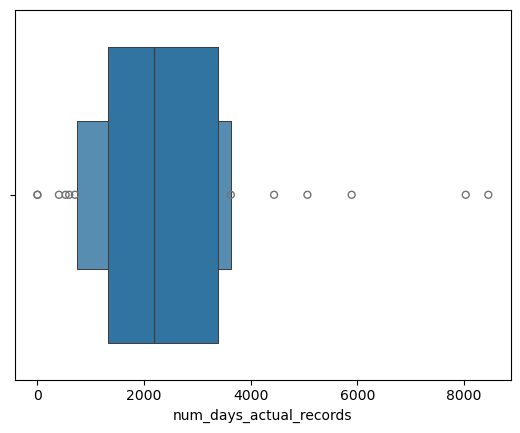

In [10]:
sns.boxenplot(
    data = rich_parquet_systems,
    x = 'num_days_actual_records'
)

In [4]:
all_data_systems.head()

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records
0,2,Residential 1a,"Lakewood, CO",America/Denver,39.7214,-105.0972,1675.0,2.912,Dfb,12,...,True,True,True,True,True,True,multi-Si,multicrystalline_Si,PVDAQ General,2180
1,3,Residential 1b,"Lakewood, CO",America/Denver,39.7214,-105.0972,1675.0,2.720,Dfb,12,...,True,True,True,True,True,True,amorphous si,thin_film,PVDAQ General,2094
2,4,NREL x-Si -1,"Golden, CO",7,39.7406,-105.1774,1795.3,1.000,BSk,12,...,True,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,5063
3,10,NREL CIS -1,"Golden, CO",7,39.7404,-105.1774,1792.8,1.120,BSk,12,...,True,True,True,True,True,True,cis family thin-film,thin_film,PVDAQ General,5893
4,33,Silicor Materials,"Golden, CO",7,39.7404,-105.1772,1794.0,2.400,BSk,12,...,True,True,True,True,True,True,Unknown,unknown,PVDAQ General,4438


## Parquet systems -- metadata survey.

In [7]:
metrics_dir = Path("../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

In [8]:
my_system_ids = list(all_data_ids.intersection(metrics_id_set))
my_system_ids.sort()
num_ids = len(my_system_ids)
num_ids

39

In [9]:
# j = 29
# system_id = my_system_ids[j]
system_id = 36
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1349,36,628,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__628
1350,36,629,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__629
1351,36,631,dc_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,dc_current__631
1352,36,633,ac_current,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current__633
1353,36,632,ac_voltage,AC voltage,V,V,1.0,0.0,,avg,NaN,NaN,,ac_voltage__632
1354,36,627,poa_irradiance_1,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,NaN,NaN,,poa_irradiance_1__627
1355,36,658,poa_irradiance_2,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,NaN,NaN,,poa_irradiance_2__658
1356,36,635,module8_temp_Top,Temperature module,C,C,1.0,0.0,,avg,NaN,NaN,,module8_temp_top__635
1357,36,636,module8_temp_Mid,Temperature module,C,C,1.0,0.0,,avg,NaN,NaN,,module8_temp_mid__636
1358,36,637,module8_temp_Bot,Temperature module,C,C,1.0,0.0,,avg,NaN,NaN,,module8_temp_bot__637


Ignore power-factor for now, re-incorporate if there is a problem.

In [8]:
my_metrics = [4792, 4793]
# grab sensor_name data of these metrics for later
relevant_rows_metrics_pruned = relevant_rows_metrics.loc[
    relevant_rows_metrics.loc[:, 'metric_id'].isin(my_metrics) #keep only rows whose metric_id is in my_metrics
]
# to keep the same sorting, re-name metric id's as follows.
metric_ids = tuple(relevant_rows_metrics_pruned.metric_id)
metric_names = tuple(relevant_rows_metrics_pruned.sensor_name)

In [9]:
access_system_dir = Path(f'../../../data_ds_project/systems/parquet/{system_id}/')
current_pq = pq.ParquetDataset(access_system_dir,
                               filters= [
                                   ('metric_id', 'in', metric_ids) #in particular, only look a the my_metric_id's
                               ])
current_df = current_pq.read().to_pandas()

In [10]:
current_2015 = current_df[current_df['measured_on'].dt.year==2015]

In [12]:
current_2015.tail()

,measured_on,utc_measured_on,metric_id,value
110447,2015-12-31 23:00:00,NaT,4793,-4.7
110448,2015-12-31 23:05:00,NaT,4793,-4.8
110449,2015-12-31 23:30:00,NaT,4793,-4.9
110450,2015-12-31 23:35:00,NaT,4793,-5.1
110451,2015-12-31 23:40:00,NaT,4793,-5.4


In [14]:
(current_2015['measured_on'] >= datetime(2015, 1, 1)).value_counts()

measured_on
True    110452
Name: count, dtype: int64

In [15]:
changeup_dict = {
    metric_ids[j]: metric_names[j] for j in range(len(my_metrics))
}

In [35]:
def manual_changer(row):
    if row.metric_id == 4792 or row.metric_id == np.int32(4792):
        return 'ambient_temp_F_TempF'
    elif row.metric_id == 4793 or row.metric_id == np.int32(4793):
        return 'module_temp_F_Temp2'
    else:
        return None

In [17]:
current_df

,measured_on,utc_measured_on,metric_id,value
0,2015-06-23 00:00:00,NaT,module_temp_F_Temp2,24.80000
1,2015-06-23 00:05:00,NaT,ambient_temp_F_TempF,30.90000
2,2015-06-23 00:20:00,NaT,ambient_temp_F_TempF,30.70000
3,2015-06-23 00:35:00,NaT,module_temp_F_Temp2,25.60000
4,2015-06-23 00:40:00,NaT,module_temp_F_Temp2,25.40000
...,...,...,...,...
555707,2020-05-28 21:45:00,2020-05-29 04:45:00,module_temp_F_Temp2,33.13334
555708,2020-05-28 22:00:00,2020-05-29 05:00:00,ambient_temp_F_TempF,33.60133
555709,2020-05-28 22:45:00,2020-05-29 05:45:00,module_temp_F_Temp2,30.80133
555710,2020-05-28 23:00:00,2020-05-29 06:00:00,ambient_temp_F_TempF,31.46667


In [53]:
current_df['utc_measured_on'].sample(n=20)

21705714                   NaT
10471069                   NaT
6927006                    NaT
14518108                   NaT
12759235                   NaT
24635606   2019-09-17 11:32:00
17912325                   NaT
31445672   2022-02-16 01:00:00
27724566   2020-09-15 07:02:00
1362881                    NaT
21669527                   NaT
25660148   2020-03-08 02:19:00
26116608   2020-04-26 05:58:00
10799478                   NaT
23862825   2019-06-01 20:21:00
20727330                   NaT
16383455                   NaT
23508565   2019-04-13 12:37:00
30013751   2021-07-31 03:02:00
17576996                   NaT
Name: utc_measured_on, dtype: datetime64[ns]

In [18]:
current_df = current_df.drop(columns=['utc_measured_on'])
current_df = current_df.drop_duplicates()

In [137]:
# debug of widening rule
current_df[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2017-11-05 02:00:00  4811         2
2017-11-05 02:15:00  4811         2
2017-11-05 02:30:00  4811         2
2017-11-05 02:45:00  4811         2
2018-11-04 02:00:00  4811         2
                                 ..
2020-05-28 22:15:00  4811         1
                     4812         1
                     5144         1
2020-05-28 22:30:00  4811         1
2020-05-28 21:15:00  4812         1
Name: count, Length: 888725, dtype: int64

In [57]:
first_example = current_df[
    current_df['measured_on'] == np.datetime64("2022-07-22 16:19:00")
]

In [58]:
first_example.sort_values(by='metric_id')

,measured_on,metric_id,value
32490833,2022-07-22 16:19:00,421,-2213.100
32490837,2022-07-22 16:19:00,421,-2200.600
32495831,2022-07-22 16:19:00,421,-2200.900
32490835,2022-07-22 16:19:00,423,33.437
32495829,2022-07-22 16:19:00,423,33.526
32495833,2022-07-22 16:19:00,423,35.825
32490838,2022-07-22 16:19:00,429,37.855
32490834,2022-07-22 16:19:00,429,37.936
32495832,2022-07-22 16:19:00,429,37.915
32494374,2022-07-22 16:19:00,430,38.073


OK, there's genuinely 2 data points registered at this time, and there is no way to know which one(s) are accurate.
For preliminary data, just average it.
Trick taken from https://stackoverflow.com/questions/33445009/pandas-new-column-from-groupby-averages

In [19]:
current_df.loc[:, 'mean_value'] = current_df.groupby(['measured_on', 'metric_id'])['value'].transform('mean')

In [70]:
first_example_again = current_df[
    current_df['measured_on'] == np.datetime64("2022-07-22 16:19:00")
]

In [61]:
first_example_again.sort_values(by='metric_id')

,measured_on,metric_id,value,mean_value
32490833,2022-07-22 16:19:00,421,-2213.100,-2204.866667
32490837,2022-07-22 16:19:00,421,-2200.600,-2204.866667
32495831,2022-07-22 16:19:00,421,-2200.900,-2204.866667
32490835,2022-07-22 16:19:00,423,33.437,34.262667
32495829,2022-07-22 16:19:00,423,33.526,34.262667
32495833,2022-07-22 16:19:00,423,35.825,34.262667
32490838,2022-07-22 16:19:00,429,37.855,37.902000
32490834,2022-07-22 16:19:00,429,37.936,37.902000
32495832,2022-07-22 16:19:00,429,37.915,37.902000
32494374,2022-07-22 16:19:00,430,38.073,38.049333


Sadly, now still duplicates, so to get my shortcut, I have to *drop* the original value and then drop-duplicates again.

In [20]:
current_df = current_df.drop(columns='value')
current_df = current_df.drop_duplicates()

In [21]:
current_df[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id           
2015-06-23 00:00:00  module_temp_F_Temp2     1
2015-06-23 00:05:00  ambient_temp_F_TempF    1
2015-06-23 00:20:00  ambient_temp_F_TempF    1
2015-06-23 00:35:00  module_temp_F_Temp2     1
2015-06-23 00:40:00  module_temp_F_Temp2     1
                                            ..
2020-05-28 21:45:00  module_temp_F_Temp2     1
2020-05-28 22:00:00  ambient_temp_F_TempF    1
2020-05-28 22:45:00  module_temp_F_Temp2     1
2020-05-28 23:00:00  ambient_temp_F_TempF    1
2020-05-28 23:45:00  module_temp_F_Temp2     1
Name: count, Length: 555696, dtype: int64

In [22]:
# to make calculations, 'widen' the frame!
current_df_wide = current_df.pivot(
    index = 'measured_on', 
    columns = 'metric_id',
    values = 'mean_value'
)
current_df_wide.columns.name = ''
current_df_wide = current_df_wide.reset_index()
current_df_wide.head()

,measured_on,ambient_temp_F_TempF,module_temp_F_Temp2
0,2015-06-23 00:00:00,30.7,24.8
1,2015-06-23 00:05:00,30.9,24.9
2,2015-06-23 00:10:00,30.9,25.0
3,2015-06-23 00:15:00,30.7,25.1
4,2015-06-23 00:20:00,30.7,24.9


In [23]:
metric_names

('module_temp_F_Temp2', 'ambient_temp_F_TempF')

In [24]:
metric_ids

(4793, 4792)

In [197]:
changeup_dict = {
    metric_ids[j]: metric_names[j] for j in range(len(my_metrics))
}
current_df_wide = current_df_wide.rename(
    columns=changeup_dict
)

In [198]:
current_df_wide.head()

,measured_on,ambient_temp_F_TempF,module_temp_F_Temp2
0,2015-06-23 00:00:00,30.7,24.8
1,2015-06-23 00:05:00,30.9,24.9
2,2015-06-23 00:10:00,30.9,25.0
3,2015-06-23 00:15:00,30.7,25.1
4,2015-06-23 00:20:00,30.7,24.9


In [199]:
current_df_wide.sample(n=20)

,measured_on,ambient_temp_F_TempF,module_temp_F_Temp2
151388,2016-11-30 04:40:00,3.000000,-1.500000
146,2015-06-23 12:10:00,37.400000,60.300000
273699,2020-04-15 18:45:00,22.367330,22.867670
198268,2017-08-08 05:45:00,26.034560,22.096330
194044,2017-06-25 05:45:00,31.700890,28.834780
225937,2018-12-05 03:30:00,3.733444,0.100222
127461,2016-09-08 01:10:00,24.400000,19.500000
64570,2016-02-02 10:40:00,5.700000,26.400000
161914,2017-01-05 19:00:00,13.800000,12.000000
160575,2017-01-01 03:25:00,5.800000,3.400000


In [113]:
np.quantile(current_df_wide.dropna().dc_power.values, 0.9)

np.float64(1061.7230000000013)

In [145]:
current_df_wide.describe()

,measured_on,module_temp_F_Temp1,ac_power_KwAC,dc_power
count,296644,295520.000000,296630.000000,296575.000000
mean,2017-04-12 18:17:52.754547200,54.602260,2607.404260,312.134892
min,2015-06-23 00:00:00,-17.777778,0.000000,0.000000
25%,2016-03-06 14:53:45,28.389436,0.100000,0.000000
50%,2016-11-19 10:37:30,50.765000,16.500000,0.000000
75%,2018-04-17 08:48:45,78.340000,100.000000,334.373000
max,2020-05-28 23:45:00,157.112000,30300.000000,136990.465000
std,NaN,33.150414,6717.247028,833.763879


In [115]:
dc_vc = current_df_wide['dc_power'].value_counts()

In [116]:
dc_vc[np.float64(-7999)]

np.int64(884)

In [200]:
systems_cleaned[systems_cleaned['system_id'] == system_id]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source
144,1418,[1418] Clark County-NV - Desert Breeze,"Clark County, NV",America/Los_Angeles,36.1253,-115.2713,779.0,42.0,Bwh,25,...,True,True,True,False,False,True,False,mono-Si,monocrystalline_Si,PVDAQ General


In [30]:
# trim zero values before graphing
current_df_trimmed = current_df_wide[
    (current_df_wide['dc_power'] > 20)
]

In [31]:
current_df_trimmed['measured_on'].dt.date.value_counts()

measured_on
2013-06-14    860
2011-06-25    857
2010-05-27    856
2010-06-24    852
2010-06-18    851
             ... 
2014-07-24      1
2014-08-14      1
2014-07-21      1
2014-07-23      1
2014-08-03      1
Name: count, Length: 1677, dtype: int64

In [95]:
current_df_trimmed.index

DatetimeIndex(['2006-01-24 09:45:00', '2006-01-24 10:00:00',
               '2006-01-24 10:15:00', '2006-01-24 10:30:00',
               '2006-01-24 10:45:00', '2006-01-24 11:00:00',
               '2006-01-24 11:15:00', '2006-01-24 11:30:00',
               '2006-01-24 11:45:00', '2006-01-24 12:00:00',
               ...
               '2023-02-28 17:00:00', '2023-02-28 17:01:00',
               '2023-02-28 17:02:00', '2023-02-28 17:03:00',
               '2023-02-28 17:04:00', '2023-02-28 17:05:00',
               '2023-02-28 17:06:00', '2023-02-28 17:07:00',
               '2023-02-28 17:08:00', '2023-02-28 17:09:00'],
              dtype='datetime64[ns]', name='measured_on', length=2515337, freq=None)

In [96]:
current_df_no_index

metric_id,measured_on,poa_irradiance,ac_power,module_temp_1,module_temp_2,module_temp_3
0,2006-01-24 09:45:00,762.040,338.5800,34.4750,33.4660,31.7950
1,2006-01-24 10:00:00,812.820,807.5300,35.1920,34.1870,32.5880
2,2006-01-24 10:15:00,859.390,845.3100,37.3130,37.2230,35.2250
3,2006-01-24 10:30:00,901.350,870.9900,38.6930,40.4490,38.9530
4,2006-01-24 10:45:00,943.160,903.5100,37.5860,40.3290,41.5640
...,...,...,...,...,...,...
2671840,2023-02-28 17:11:00,46.741,9.2573,6.7210,6.9470,6.4296
2671841,2023-02-28 17:12:00,46.034,8.9691,6.5894,6.6386,6.0682
2671842,2023-02-28 17:13:00,48.620,10.8870,6.3567,6.3953,5.8697
2671843,2023-02-28 17:14:00,49.382,10.8100,6.0699,6.2105,5.7353


In [97]:
current_df_no_index = current_df_trimmed.reset_index()

In [98]:
current_df_no_index.index

RangeIndex(start=0, stop=2515337, step=1)

In [99]:
current_df_2020 = current_df_no_index.loc[
    current_df_no_index['measured_on'].dt.year == 2020
]

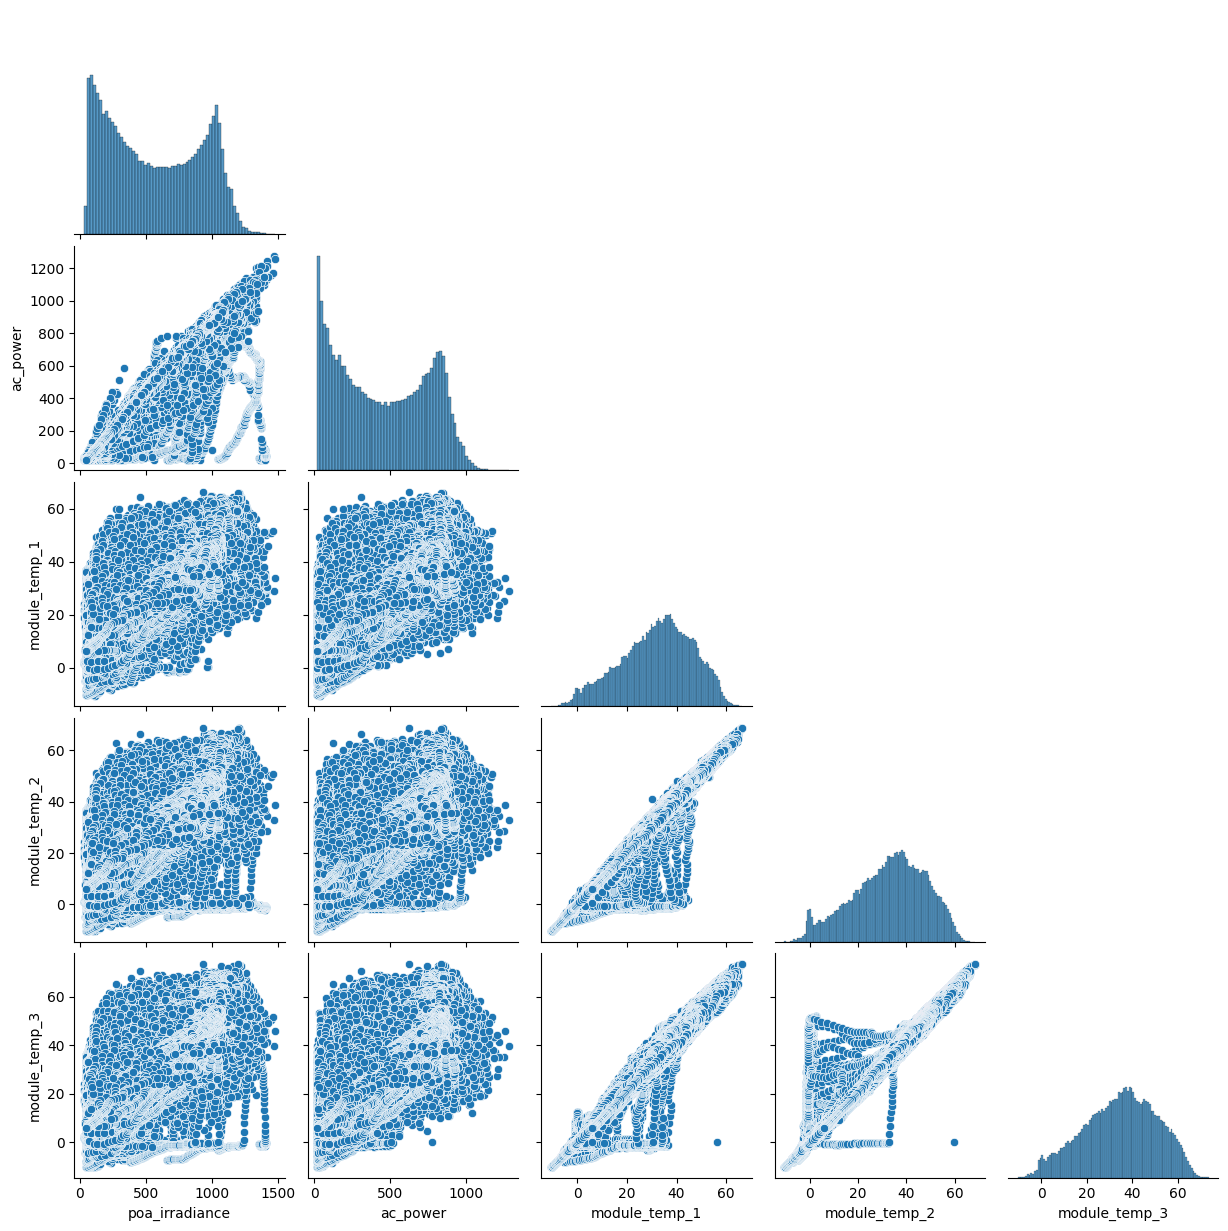

In [100]:
sns.pairplot(
    data = current_df_2020,
    corner=True
)

Clearly, for system 4, P=IV trend is obtained, but computed power may be somewhat higher!

In [ ]:
current_df_wide['abs_power_diff'] = np.abs(current_df_wide['ac_power'] - current_df_wide['power_manual'])
# remake trimmed version
current_df_trimmed = current_df_wide[
    (current_df_wide['ac_power'] > 0.5)
    & (current_df_wide['ac_current'] > 0.5)
    & (current_df_wide['ac_voltage'] > 0.5)
]

In [ ]:
current_df_trimmed['abs_power_diff'].describe()

count    2.715925e+06
mean     4.000795e+01
std      5.999898e+03
min      7.466814e-03
25%      1.587618e+01
50%      2.018221e+01
75%      2.890311e+01
max      9.887200e+06
Name: abs_power_diff, dtype: float64

So in 75% of cases, we are less than 29 Watts off, and the mean diff is 40 watts.

We say 0.5 KW (500 W) is a significant difference

In [ ]:
current_df_trimmed_sig_diff = current_df_trimmed[current_df_trimmed['abs_power_diff'] >= 500]

In [ ]:
current_df_trimmed_sig_diff.describe()

metric_id,ac_power,ac_voltage,ac_current,power_manual,abs_power_diff
count,27912.000000,2.791200e+04,27912.000000,2.791200e+04,2.791200e+04
mean,34.836998,1.657479e+02,5.104540,9.763313e+02,9.414943e+02
std,36.750065,7.319776e+03,0.632844,5.917673e+04,5.917691e+04
min,0.501000,6.480400e+01,1.913900,5.040015e+02,5.000099e+02
25%,11.224250,1.214560e+02,4.976000,6.059900e+02,5.527815e+02
50%,26.670500,1.220130e+02,5.121000,6.228639e+02,5.961663e+02
75%,53.765000,1.224850e+02,5.194000,6.336851e+02,6.202276e+02
max,1803.321000,1.223028e+06,39.429000,9.887203e+06,9.887200e+06


In [ ]:
current_df_trimmed_sig_diff.shape

(27912, 5)

Plenty of issues.